# 第5回: Python によるデータ分析入門

## 基本情報

- 主題: Python, NumPy, pandas, scikit-learn の入門
- 作成者: 荒田禎之
- 位置づけ: 機械学習を学ぶ前の準備
- 使用データ: California housing dataset
- 分析課題: 地域の所得、人口、住宅属性などから住宅価格を予測する回帰問題
- 到達目標:
  - scikit-learn のサンプルデータを Python で読み込める
  - NumPy 配列としてデータの形や数値計算を確認できる
  - pandas DataFrame として経済データに近い表形式データを確認・加工できる
  - scikit-learn で住宅価格予測の回帰モデルを学習・予測・評価できる
  - MAE, RMSE, $R^2$ を使って回帰モデルを評価できる

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

今回は、最初から最後まで同じデータを使って、Python によるデータ分析の流れを学ぶ。
scikit-learn から利用できる **California housing dataset** を使う。

このデータは、カリフォルニア州の地区ごとに、所得、築年数、部屋数、人口、緯度・経度などの情報を持ち、その地区の住宅価格の中央値を予測するためのデータである。

重要なのは、「経済データに近い表形式データを読み、確認し、加工し、回帰モデルで連続値を予測する」という分析の流れである。

---

## 2. Python の準備: 関数とオブジェクト

今回のコードでは、次のような書き方が何度も出てくる。

```python
housing = fetch_california_housing()
df.head()
df.describe()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
```

Python に慣れていない段階では、この書き方が少し分かりにくい。
そこで、最初に **関数**、**オブジェクト**、**メソッド** を簡単に確認しておく。

---

### 2.1 関数とは何か

関数とは、ある入力を受け取り、決まった処理をして、結果を返すもの。

たとえば、Python に最初から用意されている `len()` は、データの長さを返す関数である。
`len(names)` は、「`names` という入力を渡して、その長さを計算してもらう」という意味である。

In [ ]:
names = ["Aoki", "Sato", "Tanaka"]

len(names)

3

もう一つ例は `sum()` である。  
これは数値の合計を返す関数である。

In [ ]:
numbers = [10, 20, 30]

sum(numbers)

60

関数の基本形は、次のように理解するとよい。
この「入力」のことを **引数** と呼ぶ。

```python
関数名(入力)
```

---

### 2.2 自分で関数を作る

関数は、自分で作ることもできる。

In [ ]:
def add_tax(price):
    tax_included_price = price * 1.10
    return tax_included_price

この関数は、価格を受け取り、消費税込みの価格を返す。

In [ ]:
add_tax(1000)

1100.0

ここでは、`1000` が引数である。
関数の中で `1000 * 1.10` が計算され、その結果が返される。

複数の引数を取る関数も作れる。

In [ ]:
def calculate_revenue(price, quantity):
    revenue = price * quantity
    return revenue

In [ ]:
calculate_revenue(300, 5)

1500

これは、価格 300 円の商品を 5 個売ったときの売上を計算している。

このように、関数は「同じ処理を何度も使えるように名前をつけたもの」である。

---

### 2.3 今回出てくる関数

今回の資料では、次のような関数が出てくる。

```python
fetch_california_housing()
train_test_split(X, y, test_size=0.3, random_state=42)
mean_absolute_error(y_test, y_pred)
mean_squared_error(y_test, y_pred)
r2_score(y_test, y_pred)
```

たとえば、`fetch_california_housing()` は、California housing dataset を読み込む関数である。

```python
housing = fetch_california_housing()
```

これは、「`fetch_california_housing()` という関数を実行し、その結果を `housing` という変数に保存する」という意味である。

`train_test_split()` は、データを学習データとテストデータに分ける関数である。

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)
```

ここでは、`X` と `y` を入力として渡し、4 つの結果を受け取っている。

---

### 2.4 オブジェクトとは何か

Python では、多くのものが **オブジェクト** である。
オブジェクトとは、データと機能（メソッド）をまとめて持っているものだと考えるとよい。

ここで重要なのは、次の形である。
オブジェクトが持っている関数のようなものを **メソッド** と呼ぶ。

```python
オブジェクト.メソッド()
```

---

### 2.5 リストや辞書もオブジェクト

リストもオブジェクトである。

In [ ]:
values = [10, 20, 30]

values.append(40)
values

[10, 20, 30, 40]

`values` がリストのオブジェクト。
`append()` は、リストに要素を追加するメソッドである。

辞書もオブジェクトである。

In [ ]:
student = {
    "name": "Aoki",
    "grade": 3
}

student.keys()

dict_keys(['name', 'grade'])

`student` が辞書のオブジェクトである。
`keys()` は、辞書のキーを取り出すメソッドである。

---

### 2.6 pandas の DataFrame もオブジェクト

今回よく使う pandas の `DataFrame` もオブジェクトである。

```python
df.head()
df.info()
df.describe()
df.isna().sum()
```

これらはすべて、`df` という DataFrame オブジェクトに対して、メソッドを呼び出している。

- `df.head()`: 最初の数行を見る
- `df.info()`: 列名、データ型、欠損値の情報を見る
- `df.describe()`: 基本統計量を見る
- `df.isna()`: 欠損値かどうかを見る
- `df.isna().sum()`: 欠損値の数を列ごとに合計する

特に、次のようにメソッドをつなげる書き方も出てくる。

```python
df.isna().sum()
```

これは、

1. `df.isna()` で、欠損値かどうかの表を作る
2. その結果に対して `.sum()` を実行し、列ごとに合計する

という意味である。

---

### 2.7 scikit-learn のモデルもオブジェクト

scikit-learn では、モデルもオブジェクトとして扱う。

```python
model = LinearRegression()
```

これは、線形回帰モデルのオブジェクトを作り、`model` という変数に保存している。

作ったモデルには、`fit()` や `predict()` というメソッドがある。

```python
model.fit(X_train_scaled, y_train)
```

`fit()` は、学習データからモデルを学習するメソッドである。
結果は `model` という名前のオブジェクトに保存される。

```python
y_pred = model.predict(X_test_scaled)
```

`predict()` は、学習済みモデルを使って予測するメソッドである。

この一連の形は、scikit-learn のモデルで広く使われる基本形である。

---

### 2.8 関数とメソッドの違い

混乱しやすいのは、関数とメソッドの違いである。

関数は、次のように単独で呼び出す。

```python
len(values)
train_test_split(X, y)
mean_absolute_error(y_test, y_pred)
```

メソッドは、次のようにオブジェクトの後ろにつけて呼び出す。

```python
df.head()
df.describe()
model.fit(X_train_scaled, y_train)
```

厳密にはメソッドも関数の一種と考えられるが、今の段階では、

- 関数: 単独で呼び出すもの
- メソッド: オブジェクトの後ろに `.メソッド名()` と書くもの

と理解すれば十分である。

---

### 2.9 この講義で最低限読めればよい形

今回の講義では、以下の形が読めればよい。

```python
housing = fetch_california_housing()
```

関数を実行して、結果を `housing` に保存している。

```python
df = pd.DataFrame(housing.data, columns=housing.feature_names)
```

`pd.DataFrame()` という関数を使って、表形式データを作っている。

```python
df.head()
```

`df` という DataFrame オブジェクトの `head()` メソッドを呼び出す。

```python
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
```

線形回帰モデルを作り、学習し、予測し、結果を `y_pred` に保存している。

Python の文法をすべて覚える必要はない。
まずは、

> 関数を呼ぶ、オブジェクトのメソッドを呼ぶ、結果を変数に保存する

という流れを理解する事が重要である。

---

## 3. データ利用上の注意

California housing dataset は、scikit-learn の `fetch_california_housing()` で読み込む。

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

<!-- `load_diabetes()` や `load_wine()` と違い、`fetch_california_housing()` は環境によっては初回実行時にデータをダウンロードする。
授業で使う場合は、事前に教員側の環境で一度実行し、学生の実行環境でインターネット接続が必要かを確認しておくとよい。

外部アクセスが難しい授業環境では、事前にデータを取得して CSV として配布する方法もある。
ただし、この資料では scikit-learn から直接読み込む形で説明する。 -->

---

## 4. 今回使うライブラリ

まず、今回使うライブラリを読み込む。

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

それぞれの役割は次の通りである。

| ライブラリ | 今回の役割 |
|---|---|
| NumPy | 配列としてデータを扱い、平均・標準偏差などを計算する |
| pandas | DataFrame として表形式データを確認・加工・集計する |
| scikit-learn | データの読み込み、回帰モデルの学習、予測、評価を行う |

`np`, `pd` は後で参照するための略称であり、必ずしも`np`, `pd`である必要は無いが、ほとんどのケースではこの名前が使われている。
今回のポイントは、同じデータを、目的に応じて違う形で見ることである。

- NumPy: 数値のかたまりとして見る
- pandas: 行と列を持つ表として見る
- scikit-learn: 回帰モデルに入れる $X$ と $y$ として見る

---

## 5. サンプルデータを読み込む

### 5.1 fetch_california_housing を使う

In [ ]:
housing = fetch_california_housing()

型を確認する。

In [ ]:
type(housing)

sklearn.utils._bunch.Bunch

Python では、値やデータには必ず **型** がある。
型とは、そのデータがどのような種類のものかを表す情報である。

たとえば、整数、リスト、辞書、pandas の DataFrame、NumPy の配列は、それぞれ型が違う。
型が違うと、できる操作や使えるメソッドも変わる。

In [ ]:
x = 10
type(x)

int

In [ ]:
values = [1, 2, 3]
type(values)

list

In [ ]:
student = {"name": "Aoki", "grade": 3}
type(student)

dict

`fetch_california_housing()` の返り値である `housing` は、scikit-learn が用意しているデータセット用のオブジェクトである。
辞書に似た形で、`data`, `target`, `feature_names`, `DESCR` などを持っている。

そのため、次のように中に入っている情報の名前を確認できる。

In [ ]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

主に使うのは次の要素である。

| 要素 | 意味 |
|---|---|
| `data` | 特徴量データ |
| `target` | 目的変数 |
| `feature_names` | 特徴量の名前 |
| `DESCR` | データセットの説明 |

---

### 5.2 データの説明を見る

In [ ]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

説明文は長いので、すべて読む必要はないが、最低限次を確認する。

- 何を観測したデータか
- 何行あるか
- 何列の特徴量があるか
- 目的変数は何か
- 目的変数の単位は何か
- 分類問題ではなく回帰問題であること

---

## 6. NumPy として見る

### 6.1 特徴量と目的変数

In [ ]:
X = housing.data
y = housing.target

ここで、`X` は特徴量、`y` は目的変数である。

- `X`: モデルに入力する説明変数
- `y`: 予測したい住宅価格の中央値

機械学習のコードでは、この `X` と `y` という名前がよく使われる。

---

### 6.2 型を確認する

In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(y)

numpy.ndarray

どちらも NumPy の配列である。
NumPy 配列は、数値計算に向いたデータ構造である。

---

### 6.3 shape を確認する

機械学習で最初に確認すべきことの一つは、データの形である。

In [ ]:
X.shape

(20640, 8)

In [ ]:
y.shape

(20640,)

California housing dataset では、`X.shape` は `(20640, 8)` になる。
これは、

- 20640 行
- 8 列

という意味である。

つまり、20640 個の地区について、8 個の特徴量がある。
一方、`y.shape` は `(20640,)` である。
これは、20640 個の目的変数があるという意味である。

機械学習では、特徴量データを次のように考える。

$$
X \in \mathbb{R}^{n \times p}
$$

ここで、$n$ は観測数、$p$ は特徴量の数である。
回帰問題の目的変数は、長さ $n$ のベクトルである。

$$
y \in \mathbb{R}^{n}
$$

---

### 6.4 最初の数行を見る

NumPy 配列は、インデックスで一部を取り出せる。

In [ ]:
X[:5]

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02],
       [ 7.25740000e+00,  5.20000000e+01,  8.28813559e+00,
         1.07344633e+00,  4.96000000e+02,  2.80225989e+00,
         3.78500000e+01, -1.22240000e+02],
       [ 5.64310000e+00,  5.20000000e+01,  5.81735160e+00,
         1.07305936e+00,  5.58000000e+02,  2.54794521e+00,
         3.78500000e+01, -1.22250000e+02],
       [ 3.84620000e+00,  5.20000000e+01,  6.28185328e+00,
         1.08108108e+00,  5.65000000e+02,  2.18146718e+00,
         3.78500000e+01, -1.22250000e+02]])

最初の 5 行だけを見るという意味である。

1 行目だけを見る。

In [ ]:
X[0]

array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
        322.        ,    2.55555556,   37.88      , -122.23      ])

1 行目の 1 列目だけを見る。

In [ ]:
X[0, 0]

np.float64(8.3252)

最初の 5 行、最初の 3 列を見る。

In [ ]:
X[:5, :3]

array([[ 8.3252    , 41.        ,  6.98412698],
       [ 8.3014    , 21.        ,  6.23813708],
       [ 7.2574    , 52.        ,  8.28813559],
       [ 5.6431    , 52.        ,  5.8173516 ],
       [ 3.8462    , 52.        ,  6.28185328]])

NumPy では、行と列を数値で指定する。
ただし、このままだと列名が分からない。
表として理解するには、pandas の方が便利である。

---

### 6.5 平均・標準偏差を計算する

特徴量ごとの平均を計算する。

In [ ]:
X.mean(axis=0)

array([ 3.87067100e+00,  2.86394864e+01,  5.42899974e+00,  1.09667515e+00,
        1.42547674e+03,  3.07065516e+00,  3.56318614e+01, -1.19569704e+02])

特徴量ごとの標準偏差を計算する。

In [ ]:
X.std(axis=0)

array([1.89977569e+00, 1.25852527e+01, 2.47411320e+00, 4.73899376e-01,
       1.13243469e+03, 1.03857980e+01, 2.13590065e+00, 2.00348319e+00])

最小値と最大値も見る。

In [ ]:
X.min(axis=0)

array([   0.4999    ,    1.        ,    0.84615385,    0.33333333,
          3.        ,    0.69230769,   32.54      , -124.35      ])

In [ ]:
X.max(axis=0)

array([ 1.50001000e+01,  5.20000000e+01,  1.41909091e+02,  3.40666667e+01,
        3.56820000e+04,  1.24333333e+03,  4.19500000e+01, -1.14310000e+02])

`axis=0` は、列ごとに計算するという意味である。
8 個の特徴量それぞれについて、平均や標準偏差が出る。

このデータでは、特徴量によってスケールが大きく違う。
たとえば、所得、部屋数、人口、緯度、経度はそれぞれ単位も範囲も違う。
このため、線形回帰で係数を比較したい場合は、標準化を行うと扱いやすい。

---

### 6.6 目的変数を見る

回帰問題では、目的変数 `y` は連続値である。

In [ ]:
y[:10]

array([4.526, 3.585, 3.521, 3.413, 3.422, 2.697, 2.992, 2.414, 2.267,
       2.611])

目的変数の平均、標準偏差、最小値、最大値を見る。

In [ ]:
y.mean()

np.float64(2.068558169089147)

In [ ]:
y.std()

np.float64(1.1539282040412253)

In [ ]:
y.min()

np.float64(0.14999)

In [ ]:
y.max()

np.float64(5.00001)

California housing dataset の目的変数は、住宅価格の中央値であり、単位は 10 万ドルである。
たとえば、`2.0` なら、おおよそ 20 万ドルを意味する。

回帰問題では、目的変数の分布を見ることが重要である。
極端に大きい値や小さい値がある場合、モデルの評価に大きく影響する。

---

### 6.7 NumPy で学ぶべきポイント

この段階で覚えるべきことは、多くない。
重要なのは次の 5 つである。

1. `X` は 2 次元配列である
2. `y` は 1 次元配列である
3. `shape` で行数と列数を確認する
4. `axis=0` は列方向の集計である
5. NumPy は数値計算には便利だが、列名つきの表としては pandas が便利である

機械学習のエラーの多くは、データの形の齟齬から起きる。
困ったらまず `shape` を見て確認すると良い。

---

## 7. pandas として見る

### 7.1 DataFrame に変換する

NumPy 配列のままでは、列名が見えない。
そこで、pandas の DataFrame に変換する。

In [ ]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


目的変数も列として追加する。

In [ ]:
df["MedHouseVal"] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


これで、特徴量と目的変数を含む一つの表になった。

---

### 7.2 変数の意味

主な変数は次の通りである。

| 変数 | 意味 |
|---|---|
| `MedInc` | 地区の所得中央値 |
| `HouseAge` | 地区の住宅の築年数中央値 |
| `AveRooms` | 1 世帯あたり平均部屋数 |
| `AveBedrms` | 1 世帯あたり平均寝室数 |
| `Population` | 地区の人口 |
| `AveOccup` | 1 世帯あたり平均居住者数 |
| `Latitude` | 緯度 |
| `Longitude` | 経度 |
| `MedHouseVal` | 住宅価格中央値、単位は 10 万ドル |

経済データとして見ると、`MedInc` は所得、`Population` は地域規模、`Latitude` と `Longitude` は立地を表す変数である。
住宅価格は所得や立地と関係しやすいと考えられる

---

### 7.3 DataFrame の基本確認

データの先頭を見る。

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


データの末尾を見る。

In [ ]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


行数と列数を見る。

In [ ]:
df.shape

(20640, 9)

列名を見る。

In [ ]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

データ型を見る。

In [ ]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


全体の情報を見る。

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


基本統計量を見る。

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


この一連の確認は、どのデータでも最初に行う。

特に見るべき点は次の通りである。

- 行数は想定通りか
- 列数は想定通りか
- 数値列とカテゴリ列はどれか
- 欠損値はあるか
- 平均、最小値、最大値は妥当か？
- 目的変数の範囲はどのくらいか

---

### 7.4 列を選ぶ

1 つの列を選ぶ。

In [ ]:
df["MedInc"]

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


複数の列を選ぶ。

In [ ]:
df[["MedInc", "HouseAge", "AveRooms", "Population"]]

,MedInc,HouseAge,AveRooms,Population
0,8.3252,41.0,6.984127,322.0
1,8.3014,21.0,6.238137,2401.0
2,7.2574,52.0,8.288136,496.0
3,5.6431,52.0,5.817352,558.0
4,3.8462,52.0,6.281853,565.0
...,...,...,...,...
20635,1.5603,25.0,5.045455,845.0
20636,2.5568,18.0,6.114035,356.0
20637,1.7000,17.0,5.205543,1007.0
20638,1.8672,18.0,5.329513,741.0


機械学習では、特徴量と目的変数を分けるときに列選択を使う。

In [ ]:
X_df = df[housing.feature_names]
y_series = df["MedHouseVal"]

ここで、`X_df` は DataFrame、`y_series` は Series である。

In [ ]:
type(X_df)

pandas.core.frame.DataFrame

In [ ]:
type(y_series)

pandas.core.series.Series

NumPy の `X`, `y` と比べると、pandas では列名が保持される。
これは、結果を解釈するときに便利である。

---

### 7.5 行を選ぶ

条件を指定して行を取り出す。

In [ ]:
df[df["MedInc"] >= 8]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.58500
131,11.6017,18.0,8.335052,1.082474,533.0,2.747423,37.84,-122.19,3.92600
134,8.2049,28.0,6.978947,0.968421,463.0,2.436842,37.83,-122.19,3.35200
135,8.4010,26.0,7.530806,1.056872,542.0,2.568720,37.83,-122.20,3.51200
...,...,...,...,...,...,...,...,...,...
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


住宅価格が高い地区を見る。

In [ ]:
df[df["MedHouseVal"] >= 4]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
128,7.5544,40.0,7.631498,1.030581,1616.0,2.470948,37.83,-122.21,4.11500
140,6.3624,30.0,5.615385,0.730769,126.0,2.423077,37.81,-122.18,4.83300
155,8.8793,52.0,8.972868,1.131783,861.0,3.337209,37.81,-122.23,4.10300
...,...,...,...,...,...,...,...,...,...
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001
20438,7.2137,17.0,8.240664,1.033195,761.0,3.157676,34.26,-118.79,4.01900
20442,7.7785,13.0,7.969697,1.025974,833.0,3.606061,34.25,-118.78,4.04700


複数条件を使う。

In [ ]:
df[(df["MedInc"] >= 8) & (df["MedHouseVal"] >= 4)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
155,8.8793,52.0,8.972868,1.131783,861.0,3.337209,37.81,-122.23,4.10300
407,8.8342,52.0,8.345205,1.021918,975.0,2.671233,37.89,-122.27,4.30500
494,9.3959,52.0,7.512097,0.955645,1366.0,2.754032,37.85,-122.24,5.00001
510,11.8603,39.0,7.911111,0.984127,808.0,2.565079,37.82,-122.22,5.00001
...,...,...,...,...,...,...,...,...,...
20389,10.0595,26.0,8.692308,1.076923,573.0,3.148352,34.19,-118.90,5.00001
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800


`&` は「かつ」、`|` は「または」である。
条件は必ず括弧で囲む。

---

### 7.6 目的変数の分布を見る

回帰問題では、目的変数がどのような範囲にあるかを確認する。

In [ ]:
df["MedHouseVal"].describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


ヒストグラムで見る。

<Axes: >

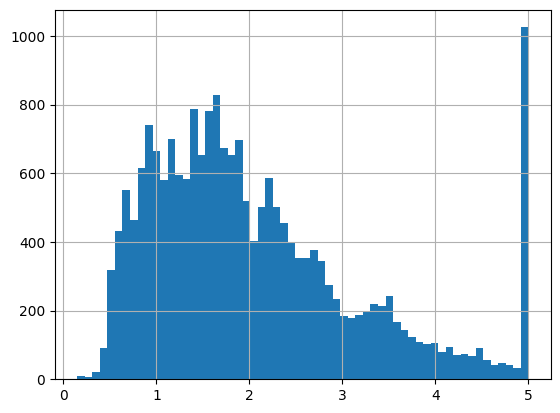

In [ ]:
df["MedHouseVal"].hist(bins=60)

California housing dataset では、目的変数の最大値付近に値が集まって見えることがある。
これは、住宅価格に上限処理がある可能性を示している。

---

### 7.7 散布図で関係を見る

所得と住宅価格の関係を見る。

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

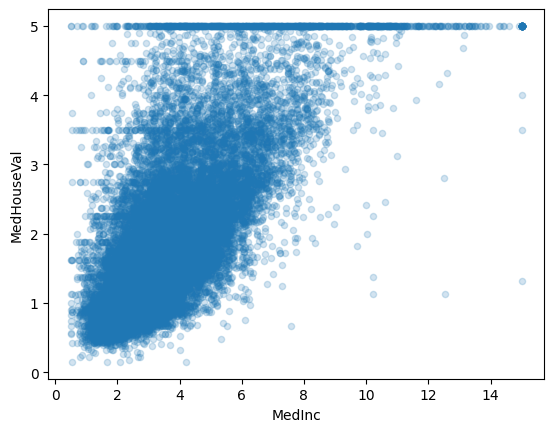

In [ ]:
df.plot.scatter(x="MedInc", y="MedHouseVal", alpha=0.2)

住宅の築年数と住宅価格の関係を見る。関係は低そうと考えられる

<Axes: xlabel='HouseAge', ylabel='MedHouseVal'>

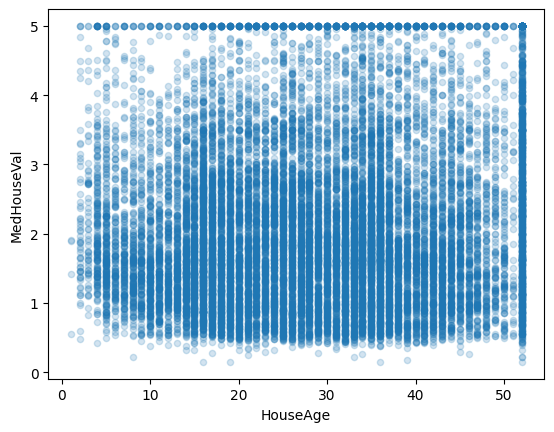

In [ ]:
df.plot.scatter(x="HouseAge", y="MedHouseVal", alpha=0.2)

地理的な分布を見る。

<Axes: xlabel='Longitude', ylabel='Latitude'>

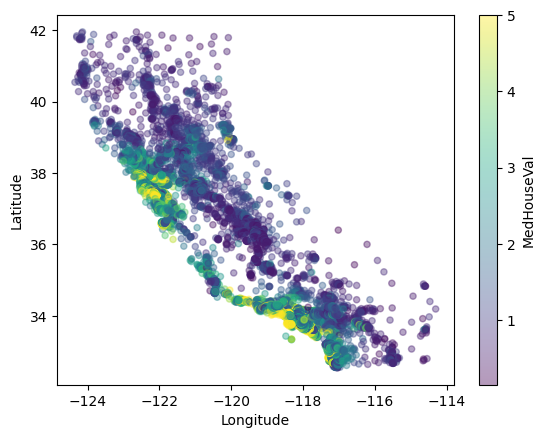

In [ ]:
df.plot.scatter(x="Longitude", y="Latitude", c="MedHouseVal", colormap="viridis", alpha=0.4)

散布図を見ると、特徴量と目的変数の関係を直感的に確認できる。
特に、緯度・経度を使うと、住宅価格に地理的な構造があることが分かる。

---

### 7.8 相関を見る

目的変数と各特徴量の相関を見る。

In [ ]:
df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


相関係数は、2 つの変数の線形的な関係の強さを表す。
値は $-1$ から $1$ の範囲を取る。

住宅価格では、所得 `MedInc` と目的変数の相関が比較的高く出ることが多い。
一方、緯度や経度のような変数は、単純な相関だけでは読み取りにくい。
これは、地理的な効果が単純な直線関係ではないためである。

---

### 7.9 欠損値を確認する

今回のデータには、基本的に欠損値はないが、実際のデータではほぼ必ずある。

In [ ]:
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


欠損値がある場合、代表的な対応は次の通りである。

- 欠損を含む行を削除する
- 平均値や中央値で埋める
- 欠損していること自体を特徴量にする

欠損値の扱いは機械学習の性能に影響する。
また、欠損がランダムでない場合、単純に削除するとデータに偏りが生じる。

---

### 7.10 pandas で学ぶべきポイント

pandas で重要なのは、表としてデータを理解できることである。

In [ ]:
df.head()
df.info()
df.describe()
df.isna().sum()
df["MedHouseVal"].describe()
df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


scikit-learn でモデルを作る前に、pandas でデータをよく見る。

---

## 8. pandas から scikit-learn へ

### 8.1 特徴量と目的変数に分ける

モデルに入れるために、特徴量 `X` と目的変数 `y` に分ける。

今回は、California housing dataset に最初から含まれている特徴量を使う。

In [ ]:
feature_cols = housing.feature_names

X = df[feature_cols]
y = df["MedHouseVal"]

形を確認する。

In [ ]:
X.shape

(20640, 8)

In [ ]:
y.shape

(20640,)

`X` は 2 次元、`y` は 1 次元である。

---

### 8.2 学習データとテストデータに分ける

データを学習用とテスト用に分ける。

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

ここでの指定は次の意味である。

- `test_size=0.3`: 30% をテストデータにする
- `random_state=42`: 結果を再現できるように乱数を固定する

分類問題では `stratify=y` を使うことが多いが、今回は回帰問題なので指定しない。

分割後の形を確認する。

In [ ]:
X_train.shape

(14448, 8)

In [ ]:
X_test.shape

(6192, 8)

In [ ]:
y_train.shape

(14448,)

In [ ]:
y_test.shape

(6192,)

---

## 9. 標準化

### 9.1 なぜ標準化するのか

California housing dataset では、特徴量の単位がかなり違う。

- `MedInc`: 所得
- `HouseAge`: 築年数
- `Population`: 人口
- `Latitude`: 緯度
- `Longitude`: 経度

標準化では、各特徴量を平均 0、標準偏差 1 に変換する。

$$
z = \frac{x - \mu}{\sigma}
$$

ここで、$\mu$ は平均、$\sigma$ は標準偏差である。

線形回帰では予測値自体はスケール変換と整合的に扱えるが、係数を比較したい場合は、標準化しておくと解釈しやすい。

---

### 9.2 StandardScaler を使う

scikit-learn では `StandardScaler` を使う。

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

重要なのは、学習データには `fit_transform()`、テストデータには `transform()` を使うことである。

- `fit`: 平均や標準偏差を学習データから計算する
- `transform`: 計算済みの平均や標準偏差を使って変換する

テストデータに対して `fit_transform()` を使ってはいけない。
テストデータの情報を前処理で使ってしまうと、評価が甘くなる。
これも **データリーク** の１つ。

---

### 9.3 標準化後の形を確認する

In [ ]:
type(X_train_scaled)

numpy.ndarray

In [ ]:
X_train_scaled.shape

(14448, 8)

`StandardScaler` の結果は NumPy 配列になる。
列名は失われる。

必要なら、DataFrame に戻すこともできる。

In [ ]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols,
    index=X_train.index
)

X_train_scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,0.133506,0.509357,0.181060,-0.273850,-0.184117,-0.010825,-0.805682,0.780934
14689,-0.532218,-0.679873,-0.422630,-0.047868,-0.376191,-0.089316,-1.339473,1.245270
17323,0.170990,-0.362745,0.073128,-0.242600,-0.611240,-0.044800,-0.496645,-0.277552
10056,-0.402916,-1.155565,0.175848,-0.008560,-0.987495,-0.075230,1.690024,-0.706938
15750,-0.299285,1.857152,-0.259598,-0.070993,0.086015,-0.066357,0.992350,-1.430902


標準化後の平均と標準偏差を確認する。

In [ ]:
X_train_scaled_df.mean()

,0
MedInc,-1.003258e-16
HouseAge,-5.286776e-17
AveRooms,3.786807e-16
AveBedrms,3.491731e-16
Population,6.786745e-17
AveOccup,1.180304e-17
Latitude,-1.464068e-15
Longitude,3.856150e-15


In [ ]:
X_train_scaled_df.std()

,0
MedInc,1.000035
HouseAge,1.000035
AveRooms,1.000035
AveBedrms,1.000035
Population,1.000035
AveOccup,1.000035
Latitude,1.000035
Longitude,1.000035


平均はほぼ 0、標準偏差はほぼ 1 になる。

---

## 10. scikit-learn で回帰モデルを作る

### 10.1 線形回帰を使う

ここでは、まず線形回帰で住宅価格を予測する。

In [ ]:
model = LinearRegression()

線形回帰は、特徴量の線形結合で目的変数を予測するモデルである。

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$

今回なら、所得、築年数、部屋数、人口、緯度・経度などを使って、住宅価格を予測する。

---

### 10.2 fit で学習する

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

`fit()` は、学習データからパターンを学ぶメソッドである。

scikit-learn では、多くのモデルが同じ形で学習できる。

今回は標準化後の `X_train_scaled` を使っている。

---

### 10.3 predict で予測する

In [ ]:
y_pred = model.predict(X_test_scaled)

`predict()` は、学習済みモデルを使って予測するメソッドである。

予測結果を見てみる。

In [ ]:
y_pred[:10]

array([0.72604907, 1.76743383, 2.71092161, 2.83514727, 2.60695807,
       2.01073856, 2.64067386, 2.16706161, 2.74012056, 3.90361526])

正解も見てみる。

In [ ]:
y_test.values[:10]

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

予測と正解を並べて確認する。

In [ ]:
result_df = pd.DataFrame({
    "true": y_test.values,
    "pred": y_pred,
    "error": y_test.values - y_pred
})

result_df.head(10)

,true,pred,error
0,0.47700,0.726049,-0.249049
1,0.45800,1.767434,-1.309434
2,5.00001,2.710922,2.289088
3,2.18600,2.835147,-0.649147
4,2.78000,2.606958,0.173042
5,1.58700,2.010739,-0.423739
6,1.98200,2.640674,-0.658674
7,1.57500,2.167062,-0.592062
8,3.40000,2.740121,0.659879
9,4.46600,3.903615,0.562385


ここでの `true` と `pred` の単位は 10 万ドルである。
誤差が `0.5` なら、おおよそ 5 万ドルのずれを意味する。

---

## 11. 回帰モデルを評価する

### 11.1 MAE

MAE は mean absolute error、平均絶対誤差である。

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mae

0.5272474538305955

数式で書くと次のようになる。

$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

MAE は、予測が平均的にどのくらい外れているかを表す。
単位が目的変数と同じなので、比較的解釈しやすい。

たとえば、MAE が `0.5` なら、平均的に 5 万ドル程度外れていると解釈できる。

---

### 11.2 MSE と RMSE

MSE は mean squared error、平均二乗誤差である。

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mse

0.5305677824766752

数式で書くと次のようになる。

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

MSE は誤差を二乗するため、大きな誤差を強く罰する。

RMSE は MSE の平方根である。

In [ ]:
rmse = np.sqrt(mse)
rmse

np.float64(0.7284008391515452)

RMSE は目的変数と同じ単位に戻るため、MSE より解釈しやすい場合がある。

---

### 11.3 $R^2$

$R^2$ は決定係数である。

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.5957702326061664

$R^2$ は、モデルが目的変数の変動をどの程度説明できているかを表す指標である。

---

### 11.4 評価をまとめて表示する

In [ ]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.5272474538305955
MSE: 0.5305677824766752
RMSE: 0.7284008391515452
R2: 0.5957702326061664


回帰では、1 つの指標だけで判断しない。
少なくとも、MAE, RMSE, $R^2$ を合わせて見るとよい。

---

### 11.5 予測値と実測値を可視化する

予測値と実測値の散布図を見る。

<Axes: xlabel='true', ylabel='pred'>

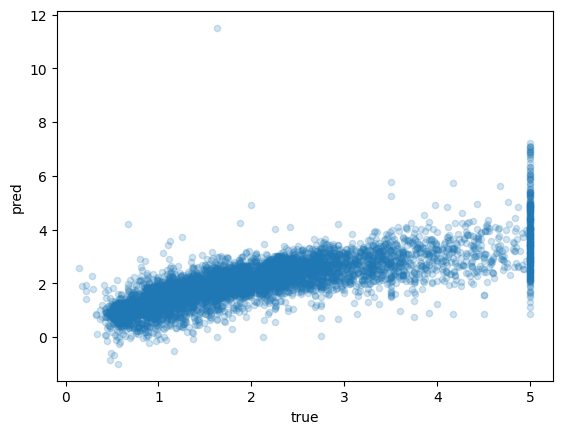

In [ ]:
result_df.plot.scatter(x="true", y="pred", alpha=0.2)

理想的には、点が右上がりの直線付近に並ぶ。
大きく外れている点があれば、その観測値を確認する。

誤差の分布を見る。

<Axes: >

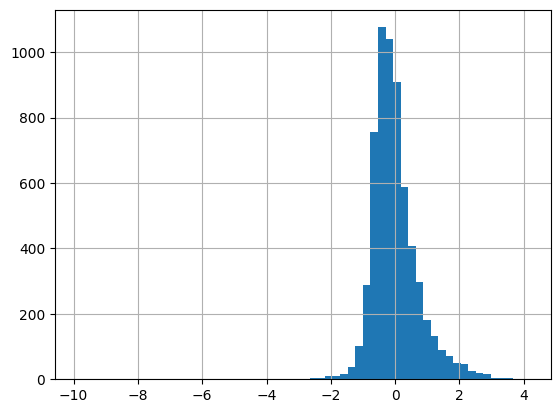

In [ ]:
result_df["error"].hist(bins=60)

誤差が特定の方向に偏っている場合、モデルが体系的に過大予測または過小予測している可能性がある。

---

## 12. モデルの中身を少し見る

### 12.1 係数を見る

線形回帰では、特徴量ごとの係数を見ることができる。

In [ ]:
model.coef_

array([ 8.49221760e-01,  1.22119309e-01, -2.99558449e-01,  3.48409673e-01,
       -8.84488134e-04, -4.16980388e-02, -8.93855649e-01, -8.68616688e-01])

係数を DataFrame にする。

In [ ]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": model.coef_
})

coef_df

,feature,coef
0,MedInc,0.849222
1,HouseAge,0.122119
2,AveRooms,-0.299558
3,AveBedrms,0.348410
4,Population,-0.000884
5,AveOccup,-0.041698
6,Latitude,-0.893856
7,Longitude,-0.868617


絶対値が大きい順に並べる。

In [ ]:
coef_df.assign(abs_coef=coef_df["coef"].abs()).sort_values("abs_coef", ascending=False)

,feature,coef,abs_coef
6,Latitude,-0.893856,0.893856
7,Longitude,-0.868617,0.868617
0,MedInc,0.849222,0.849222
3,AveBedrms,0.348410,0.348410
2,AveRooms,-0.299558,0.299558
1,HouseAge,0.122119,0.122119
5,AveOccup,-0.041698,0.041698
4,Population,-0.000884,0.000884


---

## 13. 一連の流れをまとめるコード

ここまでの流れを一つにまとめると、次のようになる。

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# データ読み込み
housing = fetch_california_housing()

# pandas DataFrame に変換
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

# 確認
print(df.shape)
print(df.head())
print(df["MedHouseVal"].describe())

# X と y
feature_cols = housing.feature_names
X = df[feature_cols]
y = df["MedHouseVal"]

# 学習データとテストデータ
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# モデル学習
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 予測
y_pred = model.predict(X_test_scaled)

# 評価
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64
MAE: 0.5272474538305955
MSE: 0.5305677824766752
RMSE: 0.7284008391515452
R2: 0.5957702326061664


このコードには、機械学習の基本的な流れがすべて入っている。

1. データを読む
2. DataFrame にする
3. データを確認する
4. `X` と `y` に分ける
5. 学習データとテストデータに分ける
6. 前処理する
7. モデルを学習する
8. 予測する
9. 評価する

今後、別の回帰モデルを使う場合も、この基本構造は大きく変わらない。

---



## 14 演習問題

### 15.1 Outlier の処理

データを眺めていると、"MedHouseVal" には値 5 周辺に上限があり、複数のサンプルがこの部分に張り付いているようだ。これは回帰分析の際には、どのように対処すればよいだろうか？

### 15.2 予測値の Outlier

予測値と実績値を見比べてみると、予測値の１つだけが異常に外れている。これの原因は何だろうか？どのように対処すべきだろうか？